In [1]:
import numpy as np

from scripts.data_loader import load_dataframe
from scripts.utils import NETWORK_TYPE

filename = "5G_data_2023.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('../data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

# # Drop unused columns to save space
matrix_cols_to_drop = ['toa_pps', 'toa_cir', 'toa_cov', 'campaign_id']
df['measurements_matrix'] = df['measurements_matrix'].apply(
    lambda x: x.drop(columns=matrix_cols_to_drop)
)

print(f"Loaded df of size {df.shape}")

Loaded dataframe from .h5 file: /Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/data/dataframe_cache/5G_data_2023.h5
Loaded df of size (33537, 4)


In [8]:
from scipy.spatial import Voronoi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update(
    {
        "font.size": 32,  # Default text size
        "axes.titlesize": 32,  # Title size
        "axes.labelsize": 32,  # X and Y label size
        "xtick.labelsize": 32,  # X tick label size
        "ytick.labelsize": 32,  # Y tick label size
        "legend.fontsize": 26,  # Legend text size
        "figure.titlesize": 32,  # Figure title size
    }
)


def make_voronoi_diagram(df: pd.DataFrame, title: str):
    cluster_centers = df.groupby('cluster')[['lat', 'lng']].mean().values

    vor = Voronoi(cluster_centers)

    # Create figure with equal aspect ratio
    fig, ax = plt.subplots(figsize=(12, 12))

    # Create a colormap with the same number of colors as clusters
    n_clusters = len(np.unique(df['cluster']))
    cmap = plt.cm.tab10  # or plt.cm.get_cmap('tab10')

    # Plot the data points colored by cluster
    scatter = ax.scatter(df['lng'], df['lat'], c=df['cluster'], cmap='tab10', alpha=0.6, s=50)

    # Function to get finite vertices for infinite regions
    def voronoi_finite_polygons_2d(vor, radius=None):
        if vor.points.shape[1] != 2:
            raise ValueError("Requires 2D input")

        new_regions = []
        new_vertices = vor.vertices.tolist()

        center = vor.points.mean(axis=0)
        if radius is None:
            radius = np.max(np.max(vor.points, axis=0) - np.min(vor.points, axis=0)) * 2

        # Construct a map containing all ridges for a given point
        all_ridges = {}
        for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
            all_ridges.setdefault(p1, []).append((p2, v1, v2))
            all_ridges.setdefault(p2, []).append((p1, v1, v2))

        # Reconstruct infinite regions
        for p1, region in enumerate(vor.point_region):
            vertices = vor.regions[region]

            if all(v >= 0 for v in vertices):
                # finite region
                new_regions.append(vertices)
                continue

            # reconstruct a non-finite region
            ridges = all_ridges[p1]
            new_region = [v for v in vertices if v >= 0]

            for p2, v1, v2 in ridges:
                if v2 < 0:
                    v1, v2 = v2, v1
                if v1 >= 0:
                    # finite ridge: already in the region
                    continue

                # Compute the missing endpoint of an infinite ridge
                t = vor.points[p2] - vor.points[p1]  # tangent
                t /= np.linalg.norm(t)
                n = np.array([-t[1], t[0]])  # normal

                midpoint = vor.points[[p1, p2]].mean(axis=0)
                direction = np.sign(np.dot(midpoint - center, n)) * n
                far_point = vor.vertices[v2] + direction * radius

                new_region.append(len(new_vertices))
                new_vertices.append(far_point.tolist())

            # sort region counterclockwise
            vs = np.asarray([new_vertices[v] for v in new_region])
            c = vs.mean(axis=0)
            angles = np.arctan2(vs[:, 1] - c[1], vs[:, 0] - c[0])
            new_region = np.array(new_region)[np.argsort(angles)]

            new_regions.append(new_region.tolist())

        return new_regions, np.asarray(new_vertices)

    # Get finite polygons
    regions, vertices = voronoi_finite_polygons_2d(vor)

    # Create a mapping from cluster center to cluster label
    center_to_label = {}
    for i, center in enumerate(cluster_centers):
        # Find the closest points to this center
        closest_points = df.iloc[(((df['lat'] - center[0]) ** 2 +
                                   (df['lng'] - center[1]) ** 2) ** 0.5).argsort()[:1]]
        center_to_label[i] = closest_points['cluster'].iloc[0]

    # Plot Voronoi regions with matching colors
    for i, region in enumerate(regions):
        polygon = vertices[region]
        cluster_label = center_to_label[i]
        ax.fill(polygon[:, 1], polygon[:, 0],
                color=cmap(cluster_label / n_clusters),  # Use same color mapping as scatter
                alpha=0.2,
                edgecolor='black')

    # Plot cluster centers
    ax.scatter(cluster_centers[:, 1], cluster_centers[:, 0],
               c='red', marker='o', alpha=1, s=200, linewidths=3, label='Cluster Centers')

    # Set limits with buffer
    buffer = 0.001  # Adjust this value to control zoom level
    x_min, x_max = df['lng'].min() - buffer, df['lng'].max() + buffer
    y_min, y_max = df['lat'].min() - buffer, df['lat'].max() + buffer
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Set equal aspect ratio
    ax.set_aspect('equal')

    # Format ticks to show full coordinate values
    def format_coord(x, places=2):
        return f'{x:.{places}f}'

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format_coord(x)))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format_coord(x)))

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.legend(borderpad=1.0, loc='upper right')
    ax.grid(True)

    plt.tight_layout()
    plt.show()


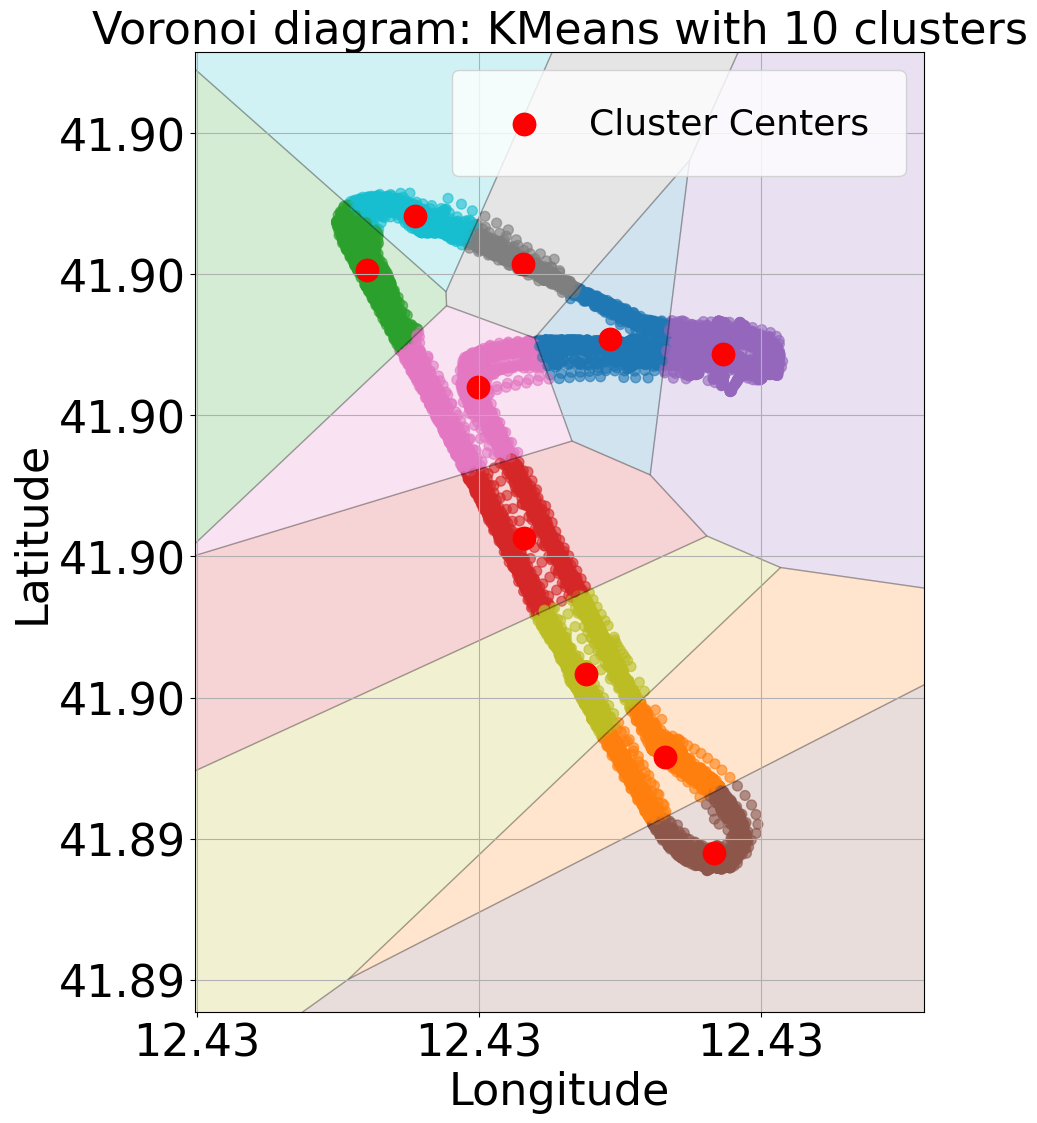

In [9]:
from scripts.clustering import train_kmeans

cluster_sizes = [10]

for size in cluster_sizes:
    tmp = df.copy()
    _, cluster_labels = train_kmeans(tmp, size, 42)
    tmp["cluster"] = cluster_labels

    make_voronoi_diagram(tmp, title=(f"Voronoi diagram: KMeans with {size} clusters"))
